In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Daten laden
df = pd.read_csv('../data/processed/cleaned_data.csv')

# 2. Features (X) und Target (y) definieren
features = [
    'air_temperature', 'process_temperature', 'rotational_speed', 
    'torque', 'tool_wear', 'temp_difference', 'power_w', 'overstrain_index'
]
X = df[features]
y = df['machine_failure']

# 3. Train-Test-Split (80% Training, 20% Test) mit Stratify (wegen Unwucht der Klassen)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Modell trainieren
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. Evaluierung
y_pred = model.predict(X_test)
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.90      0.78      0.83        68

    accuracy                           0.99      2000
   macro avg       0.95      0.89      0.91      2000
weighted avg       0.99      0.99      0.99      2000



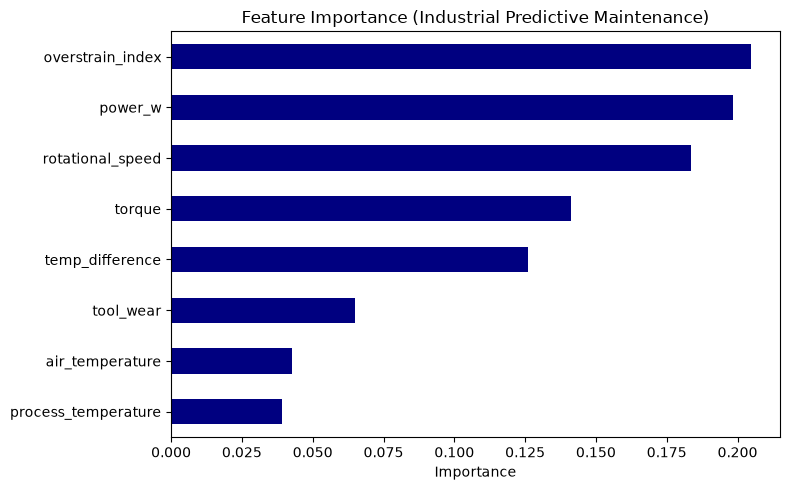

--- Classification Report (Balanced Class Weights) ---
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1932
           1       0.90      0.82      0.86        68

    accuracy                           0.99      2000
   macro avg       0.95      0.91      0.93      2000
weighted avg       0.99      0.99      0.99      2000



In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 1. Feature Importance visualisieren
importances = model.feature_importances_
feature_names = features
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
feat_imp.plot(kind='barh', color='navy')
plt.title('Feature Importance (Industrial Predictive Maintenance)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../reports/feature_importance.png')
plt.show()

# 2. Modellierung mit Balanced Class Weights (gegen Unwucht der Daten)
model_balanced = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model_balanced.fit(X_train, y_train)

y_pred_balanced = model_balanced.predict(X_test)

print("--- Classification Report (Balanced Class Weights) ---")
print(classification_report(y_test, y_pred_balanced))

Best Parameters: {'class_weight': 'balanced', 'max_depth': 20, 'n_estimators': 200}

--- Optimized Classification Report ---
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1932
           1       0.90      0.82      0.86        68

    accuracy                           0.99      2000
   macro avg       0.95      0.91      0.93      2000
weighted avg       0.99      0.99      0.99      2000

ROC-AUC Score: 0.9785


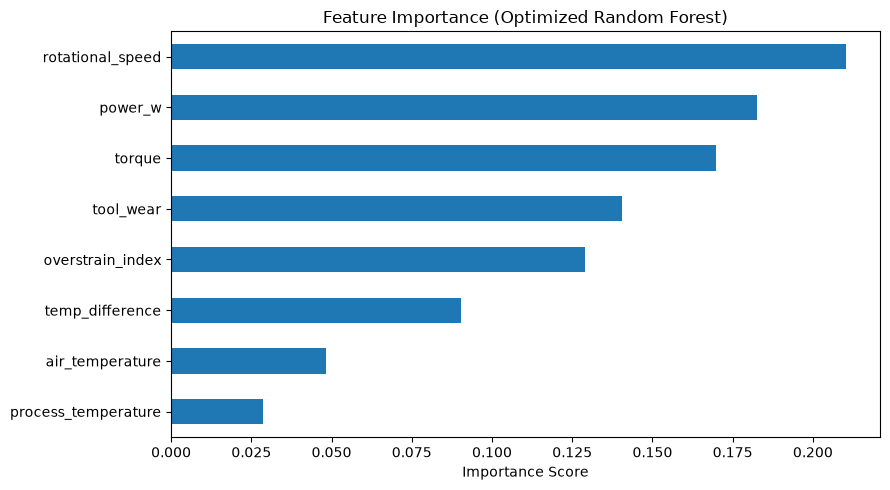

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Sicherstellen, dass der Ordner 'reports' existiert
os.makedirs('../reports', exist_ok=True)

# 2. Daten laden
df = pd.read_csv('../data/processed/cleaned_data.csv')

features = [
    'air_temperature', 'process_temperature', 'rotational_speed', 
    'torque', 'tool_wear', 'temp_difference', 'power_w', 'overstrain_index'
]
X = df[features]
y = df['machine_failure']

# Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. GridSearchCV für Hyperparameter-Tuning & Class Weights
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'class_weight': ['balanced', 'balanced_subsample']
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

# 4. Modell-Evaluierung
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("\n--- Optimized Classification Report ---")
print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_proba), 4))

# 5. Feature Importance Plot generieren & speichern
importances = best_model.feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
feat_imp.plot(kind='barh', color='#1f77b4')
plt.title('Feature Importance (Optimized Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../reports/feature_importance.png')
plt.show()